In [2]:
import sys, statistics, time, string, random, seaborn as sns, pickle, joblib
import matplotlib.pyplot as plt, matplotlib.animation as animation
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef
from sklearn.utils.multiclass import unique_labels
from RFMN import ReflexFuzzyNeuroNetwork

sensorData = pd.read_csv('features_train_test.csv')
sensorData = sensorData.iloc[:,1:]


print(sensorData.head())

   Time  Force  X_axis  Y_axis  Z_axis  Class
0  0.02      0   -78.0   420.0 -2508.0      1
1  0.04      0   -73.5   418.5 -2508.0      1
2  0.06      0   -72.0   421.5 -2508.0      1
3  0.08      0   -75.0   417.0 -2508.0      1
4   0.1      1   -69.0   418.5 -2509.5      1


In [3]:
numClasses = 4

classOne = sensorData.iloc[:int(1*(len(sensorData)/numClasses)), :]
print(classOne)
classTwo = sensorData.iloc[int(1*(len(sensorData)/numClasses)):int(2*(len(sensorData)/numClasses)), :]
print(classTwo)
classThree = sensorData.iloc[int(2*(len(sensorData)/numClasses)):int(3*(len(sensorData)/numClasses)), :]
print(classThree)
classFour = sensorData.iloc[int(3*(len(sensorData)/numClasses)):int(4*(len(sensorData)/numClasses)), :]
print(classFour)

Time = np.arange(int(1*(len(sensorData)/numClasses)))

         Time  Force  X_axis  Y_axis  Z_axis  Class
0        0.02      0   -78.0   420.0 -2508.0      1
1        0.04      0   -73.5   418.5 -2508.0      1
2        0.06      0   -72.0   421.5 -2508.0      1
3        0.08      0   -75.0   417.0 -2508.0      1
4         0.1      1   -69.0   418.5 -2509.5      1
...       ...    ...     ...     ...     ...    ...
3995  79.9186      0   -82.5   415.5 -2524.5      1
3996  79.9386      0   -79.5   420.0 -2524.5      1
3997  79.9586      0   -85.5   415.5 -2524.5      1
3998  79.9786      2   -85.5   417.0 -2524.5      1
3999  79.9986      0   -82.5   421.5 -2526.0      1

[4000 rows x 6 columns]
         Time  Force  X_axis  Y_axis  Z_axis  Class
4000               0  -112.5   574.5 -2802.0      2
4001     0.04     -1  -123.0   591.0 -2829.0      2
4002     0.06      0  -115.5   594.0 -2824.5      2
4003     0.08      0  -117.0   591.0 -2824.5      2
4004      0.1     -1  -112.5   591.0 -2821.5      2
...       ...    ...     ...     ...   

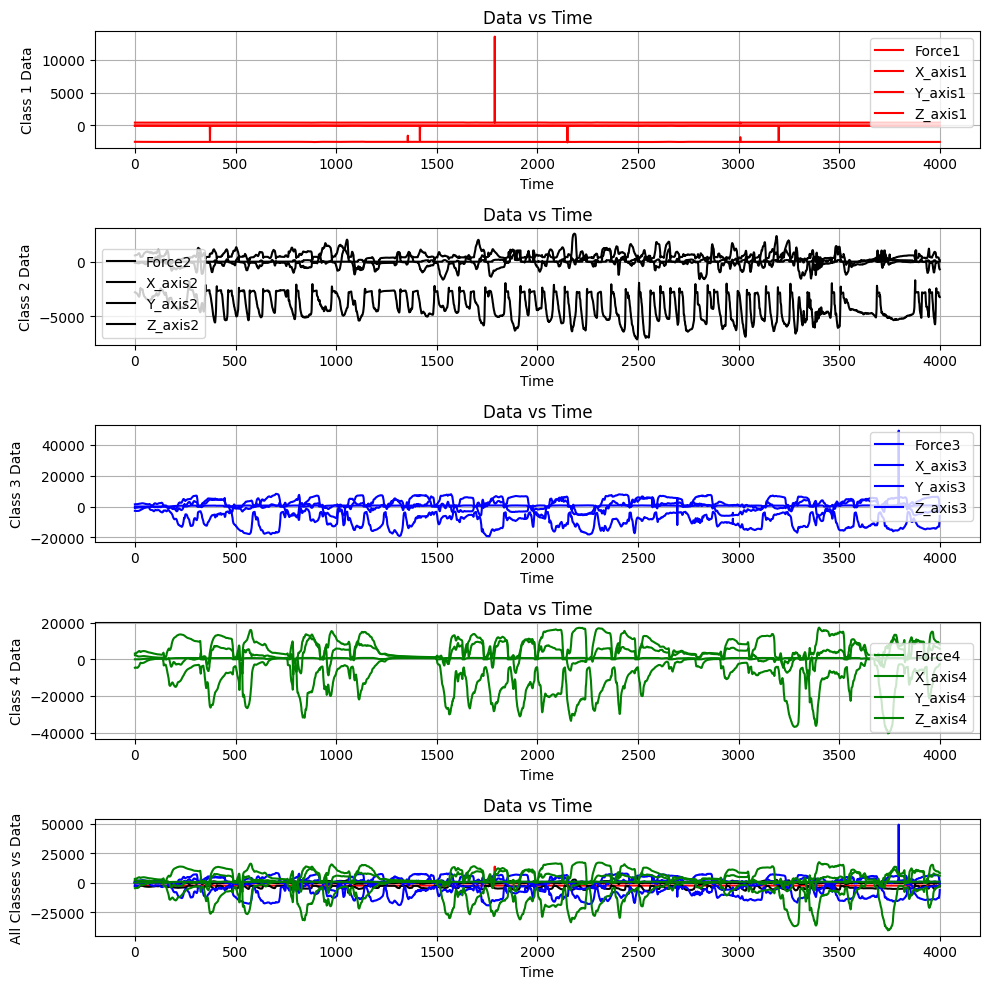

In [4]:
plt.figure("ArduinoDataAnalysis", figsize=(10, 10))

plt.subplot(5, 1, 1)
plt.plot(Time, classOne['Force'], label='Force1', color='r')
plt.plot(Time, classOne['X_axis'], label='X_axis1', color='r')
plt.plot(Time, classOne['Y_axis'], label='Y_axis1', color='r')
plt.plot(Time, classOne['Z_axis'], label='Z_axis1', color='r')
plt.xlabel('Time')
plt.ylabel('Class 1 Data')
plt.title('Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(Time, classTwo['Force'], label='Force2', color='k')
plt.plot(Time, classTwo['X_axis'], label='X_axis2', color='k')
plt.plot(Time, classTwo['Y_axis'], label='Y_axis2', color='k')
plt.plot(Time, classTwo['Z_axis'], label='Z_axis2', color='k')
plt.xlabel('Time')
plt.ylabel('Class 2 Data')
plt.title('Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(Time, classThree['Force'], label='Force3', color='b')
plt.plot(Time, classThree['X_axis'], label='X_axis3', color='b')
plt.plot(Time, classThree['Y_axis'], label='Y_axis3', color='b')
plt.plot(Time, classThree['Z_axis'], label='Z_axis3', color='b')
plt.xlabel('Time')
plt.ylabel('Class 3 Data')
plt.title('Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(Time, classFour['Force'], label='Force4', color='g')
plt.plot(Time, classFour['X_axis'], label='X_axis4', color='g')
plt.plot(Time, classFour['Y_axis'], label='Y_axis4', color='g')
plt.plot(Time, classFour['Z_axis'], label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('Class 4 Data')
plt.title('Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(Time, classOne['Force'], label='Force1', color='r')
plt.plot(Time, classOne['X_axis'], label='X_axis1', color='r')
plt.plot(Time, classOne['Y_axis'], label='Y_axis1', color='r')
plt.plot(Time, classOne['Z_axis'], label='Z_axis1', color='r')

plt.plot(Time, classTwo['Force'], label='Force2', color='k')
plt.plot(Time, classTwo['X_axis'], label='X_axis2', color='k')
plt.plot(Time, classTwo['Y_axis'], label='Y_axis2', color='k')
plt.plot(Time, classTwo['Z_axis'], label='Z_axis2', color='k')

plt.plot(Time, classThree['Force'], label='Force3', color='b')
plt.plot(Time, classThree['X_axis'], label='X_axis3', color='b')
plt.plot(Time, classThree['Y_axis'], label='Y_axis3', color='b')
plt.plot(Time, classThree['Z_axis'], label='Z_axis3', color='b')

plt.plot(Time, classFour['Force'], label='Force4', color='g')
plt.plot(Time, classFour['X_axis'], label='X_axis4', color='g')
plt.plot(Time, classFour['Y_axis'], label='Y_axis4', color='g')
plt.plot(Time, classFour['Z_axis'], label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('All Classes vs Data')
plt.title('Data vs Time')
plt.grid(True)

plt.tight_layout()
plt.show()


In [5]:
# Start applying smooth filters

# The running mean filter
def average_filter(data, window_size):
    ave_filter = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    return ave_filter

window_size = 50  # Set to frequency level. 
# ave_filt_time = np.arange(int(1*(len(sensorData)/numClasses)) - window_size + 1 )

# Time[window_size-1:]
# print(Time[window_size-1:])
# print(len(Time[window_size-1:]))


# print(ave_filt_time)
# print(len(ave_filt_time))


classOne_ave_filt_force = average_filter(classOne['Force'], window_size)
classOne_ave_filt_xaxis = average_filter(classOne['X_axis'], window_size)
classOne_ave_filt_yaxis = average_filter(classOne['Y_axis'], window_size)
classOne_ave_filt_zaxis = average_filter(classOne['Z_axis'], window_size)

print(classOne_ave_filt_force)
print(classOne_ave_filt_xaxis)
print(classOne_ave_filt_yaxis)
print(classOne_ave_filt_zaxis)

print(len(classOne_ave_filt_force))
print(len(classOne_ave_filt_xaxis))
print(len(classOne_ave_filt_yaxis))
print(len(classOne_ave_filt_zaxis))

classTwo_ave_filt_force = average_filter(classTwo['Force'], window_size)
classTwo_ave_filt_xaxis = average_filter(classTwo['X_axis'], window_size)
classTwo_ave_filt_yaxis = average_filter(classTwo['Y_axis'], window_size)
classTwo_ave_filt_zaxis = average_filter(classTwo['Z_axis'], window_size)

print(classTwo_ave_filt_force)
print(classTwo_ave_filt_xaxis)
print(classTwo_ave_filt_yaxis)
print(classTwo_ave_filt_zaxis)

print(len(classTwo_ave_filt_force))
print(len(classTwo_ave_filt_xaxis))
print(len(classTwo_ave_filt_yaxis))
print(len(classTwo_ave_filt_zaxis))

classThree_ave_filt_force = average_filter(classThree['Force'], window_size)
classThree_ave_filt_xaxis = average_filter(classThree['X_axis'], window_size)
classThree_ave_filt_yaxis = average_filter(classThree['Y_axis'], window_size)
classThree_ave_filt_zaxis = average_filter(classThree['Z_axis'], window_size)

print(classThree_ave_filt_force)
print(classThree_ave_filt_xaxis)
print(classThree_ave_filt_yaxis)
print(classThree_ave_filt_zaxis)

print(len(classThree_ave_filt_force))
print(len(classThree_ave_filt_xaxis))
print(len(classThree_ave_filt_yaxis))
print(len(classThree_ave_filt_zaxis))

classFour_ave_filt_force = average_filter(classFour['Force'], window_size)
classFour_ave_filt_xaxis = average_filter(classFour['X_axis'], window_size)
classFour_ave_filt_yaxis = average_filter(classFour['Y_axis'], window_size)
classFour_ave_filt_zaxis = average_filter(classFour['Z_axis'], window_size)

print(classFour_ave_filt_force)
print(classFour_ave_filt_xaxis)
print(classFour_ave_filt_yaxis)
print(classFour_ave_filt_zaxis)

print(len(classFour_ave_filt_force))
print(len(classFour_ave_filt_xaxis))
print(len(classFour_ave_filt_yaxis))
print(len(classFour_ave_filt_zaxis))





[-0.06 -0.06 -0.06 ... -0.22 -0.16 -0.16]
[-72.51 -72.36 -72.3  ... -77.28 -77.43 -77.61]
[419.79 419.76 419.82 ... 416.46 416.34 416.4 ]
[-2507.16 -2507.16 -2507.16 ... -2521.02 -2521.2  -2521.38]
3951
3951
3951
3951
[-0.32 -0.32 -0.28 ... 20.62 20.64 20.66]
[-123.84 -125.79 -127.74 ... -278.88 -290.25 -303.33]
[614.04 618.96 623.88 ... 514.47 508.56 501.6 ]
[-2862.75 -2871.39 -2880.12 ... -3543.33 -3556.53 -3565.74]
3951
3951
3951
3951
[-1.4000e-01 -1.4000e-01 -1.4000e-01 ...  6.8464e+02  6.6994e+02
  6.5526e+02]
[ -706.14  -700.53  -694.62 ... -3103.26 -3068.67 -3016.47]
[1799.94 1806.45 1811.1  ... 5959.11 5869.74 5764.65]
[ -2219.91  -2178.39  -2136.06 ... -13829.49 -13719.87 -13553.91]
3951
3951
3951
3951
[ 88.58  94.56 100.6  ... 742.8  744.66 746.3 ]
[1784.88 1773.9  1761.93 ... 6301.05 6286.95 6280.68]
[ 4119.42  4144.56  4168.98 ... 11437.56 11408.82 11358.42]
[-3086.13 -3023.22 -2962.62 ... -9427.08 -9055.44 -8685.42]
3951
3951
3951
3951


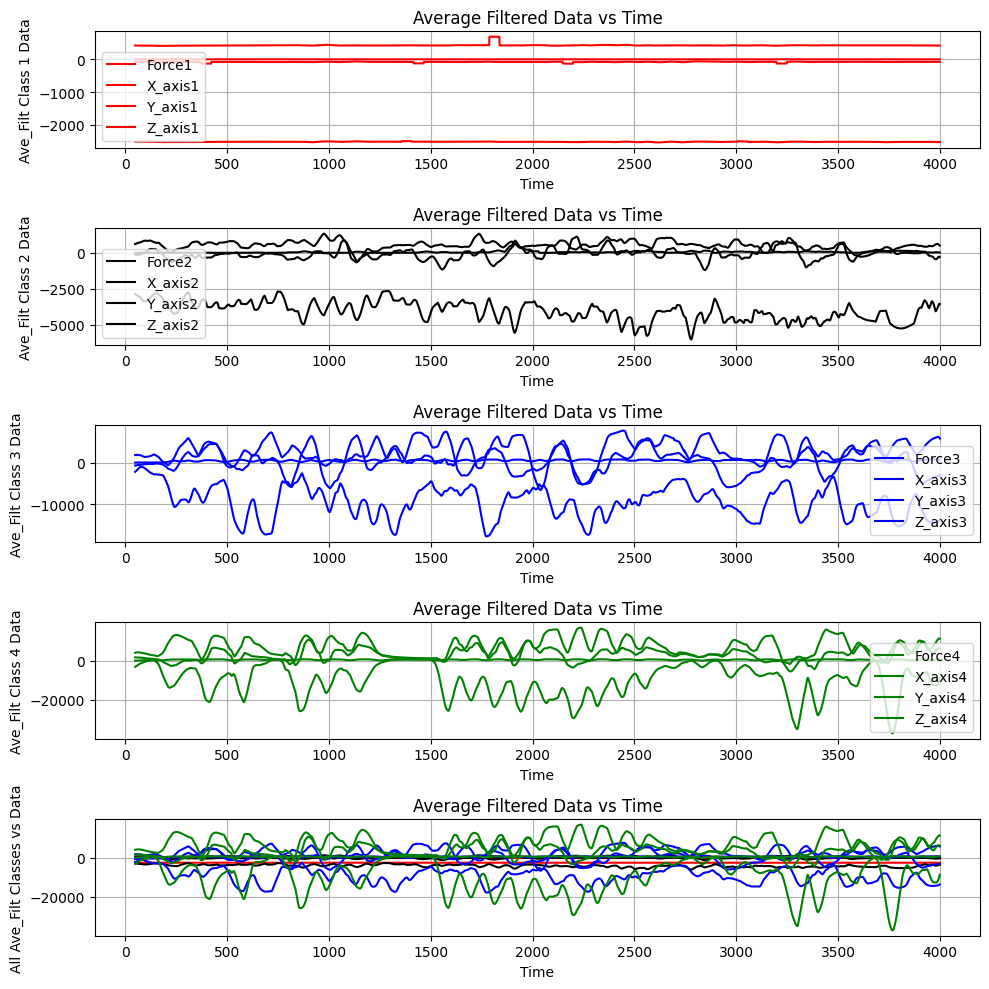

In [6]:
plt.figure("AverageFilteredDataAnalysis", figsize=(10, 10))


plt.subplot(5, 1, 1)
plt.plot(Time[window_size-1:], classOne_ave_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_xaxis, label='X_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_yaxis, label='Y_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_zaxis , label='Z_axis1', color='r')
plt.xlabel('Time')
plt.ylabel('Ave_Filt Class 1 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(Time[window_size-1:], classTwo_ave_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_xaxis, label='X_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_yaxis, label='Y_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_zaxis, label='Z_axis2', color='k')
plt.xlabel('Time')
plt.ylabel('Ave_Filt Class 2 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(Time[window_size-1:], classThree_ave_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_xaxis, label='X_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_yaxis, label='Y_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_zaxis, label='Z_axis3', color='b')
plt.xlabel('Time')
plt.ylabel('Ave_Filt Class 3 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(Time[window_size-1:], classFour_ave_filt_force, label='Force4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_xaxis, label='X_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_yaxis, label='Y_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_zaxis, label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('Ave_Filt Class 4 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(Time[window_size-1:], classOne_ave_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_xaxis, label='X_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_yaxis, label='Y_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_zaxis , label='Z_axis1', color='r')

plt.plot(Time[window_size-1:], classTwo_ave_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_xaxis, label='X_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_yaxis, label='Y_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_zaxis, label='Z_axis2', color='k')

plt.plot(Time[window_size-1:], classThree_ave_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_xaxis, label='X_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_yaxis, label='Y_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_zaxis, label='Z_axis3', color='b')

plt.plot(Time[window_size-1:], classFour_ave_filt_force, label='Force4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_xaxis, label='X_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_yaxis, label='Y_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_zaxis, label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('All Ave_Filt Classes vs Data')
plt.title('Average Filtered Data vs Time')
plt.grid(True)

plt.tight_layout()
plt.show()




In [7]:
# The moving median filter
def median_filter(data, window_size):
    return np.array([np.median(data[i:i+window_size]) for i in range(len(data)-window_size+1)])


classOne_med_filt_force = median_filter(classOne['Force'], window_size)
classOne_med_filt_xaxis = median_filter(classOne['X_axis'], window_size)
classOne_med_filt_yaxis = median_filter(classOne['Y_axis'], window_size)
classOne_med_filt_zaxis = median_filter(classOne['Z_axis'], window_size)

print(classOne_med_filt_force)
print(classOne_med_filt_xaxis)
print(classOne_med_filt_yaxis)
print(classOne_med_filt_zaxis)

print(len(classOne_med_filt_force))
print(len(classOne_med_filt_xaxis))
print(len(classOne_med_filt_yaxis))
print(len(classOne_med_filt_zaxis))

classTwo_med_filt_force = median_filter(classTwo['Force'], window_size)
classTwo_med_filt_xaxis = median_filter(classTwo['X_axis'], window_size)
classTwo_med_filt_yaxis = median_filter(classTwo['Y_axis'], window_size)
classTwo_med_filt_zaxis = median_filter(classTwo['Z_axis'], window_size)

classThree_med_filt_force = median_filter(classThree['Force'], window_size)
classThree_med_filt_xaxis = median_filter(classThree['X_axis'], window_size)
classThree_med_filt_yaxis = median_filter(classThree['Y_axis'], window_size)
classThree_med_filt_zaxis = median_filter(classThree['Z_axis'], window_size)


classFour_med_filt_force = median_filter(classFour['Force'], window_size)
classFour_med_filt_xaxis = median_filter(classFour['X_axis'], window_size)
classFour_med_filt_yaxis = median_filter(classFour['Y_axis'], window_size)
classFour_med_filt_zaxis = median_filter(classFour['Z_axis'], window_size)
print(classFour_med_filt_force)
print(classFour_med_filt_xaxis)
print(classFour_med_filt_yaxis)
print(classFour_med_filt_zaxis)






[0. 0. 0. ... 0. 0. 0.]
[-72.   -72.   -72.   ... -76.5  -76.5  -77.25]
[420.  420.  420.  ... 415.5 415.5 415.5]
[-2506.5 -2506.5 -2506.5 ... -2521.5 -2521.5 -2521.5]
3951
3951
3951
3951


C:\Users\dema2\AppData\Local\Temp\ipykernel_12708\3700228699.py:3: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  return np.array([np.median(data[i:i+window_size]) for i in range(len(data)-window_size+1)])


[ 39.   41.5  46.  ... 753.  753.  753.5]
[1734.75 1732.5  1730.25 ... 6393.75 6318.   6318.  ]
[ 4311.75  4333.5   4368.75 ... 10559.25 10559.25 10514.25]
[-2611.5  -2280.   -2139.75 ... -6287.25 -5970.   -5638.5 ]


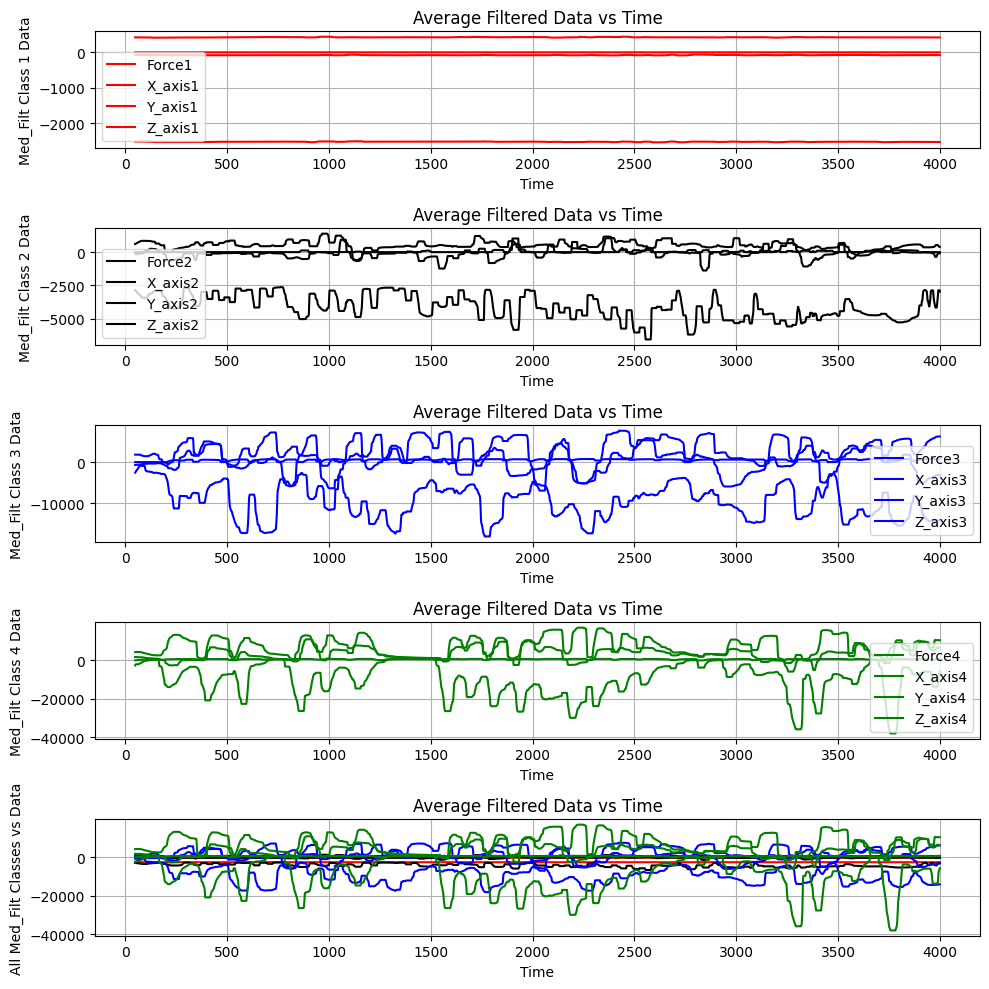

In [8]:
plt.figure("MedianFilteredDataAnalysis", figsize=(10, 10))

plt.subplot(5, 1, 1)
plt.plot(Time[window_size-1:], classOne_med_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_xaxis, label='X_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_yaxis, label='Y_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_zaxis , label='Z_axis1', color='r')
plt.xlabel('Time')
plt.ylabel('Med_Filt Class 1 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(Time[window_size-1:], classTwo_med_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_xaxis, label='X_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_yaxis, label='Y_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_zaxis, label='Z_axis2', color='k')
plt.xlabel('Time')
plt.ylabel('Med_Filt Class 2 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(Time[window_size-1:], classThree_med_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_xaxis, label='X_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_yaxis, label='Y_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_zaxis, label='Z_axis3', color='b')
plt.xlabel('Time')
plt.ylabel('Med_Filt Class 3 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(Time[window_size-1:], classFour_med_filt_force, label='Force4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_xaxis, label='X_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_yaxis, label='Y_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_zaxis, label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('Med_Filt Class 4 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(Time[window_size-1:], classOne_med_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_xaxis, label='X_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_yaxis, label='Y_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_zaxis , label='Z_axis1', color='r')

plt.plot(Time[window_size-1:], classTwo_med_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_xaxis, label='X_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_yaxis, label='Y_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_zaxis, label='Z_axis2', color='k')

plt.plot(Time[window_size-1:], classThree_med_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_xaxis, label='X_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_yaxis, label='Y_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_zaxis, label='Z_axis3', color='b')

plt.plot(Time[window_size-1:], classFour_med_filt_force, label='Force4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_xaxis, label='X_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_yaxis, label='Y_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_zaxis, label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('All Med_Filt Classes vs Data')
plt.title('Average Filtered Data vs Time')
plt.grid(True)

plt.tight_layout()
plt.show()




In [9]:
combined_ave_filt_force = np.concatenate((classOne_ave_filt_force,classTwo_ave_filt_force,
                                          classThree_ave_filt_force,classFour_ave_filt_force))
print(combined_ave_filt_force)


combined_ave_filt_xaxis = np.concatenate((classOne_ave_filt_xaxis,classTwo_ave_filt_xaxis,
                                          classThree_ave_filt_xaxis,classFour_ave_filt_xaxis))
print(combined_ave_filt_xaxis)


combined_ave_filt_yaxis = np.concatenate((classOne_ave_filt_yaxis,classTwo_ave_filt_yaxis,
                                          classThree_ave_filt_yaxis,classFour_ave_filt_yaxis))
print(combined_ave_filt_yaxis)


combined_ave_filt_zaxis = np.concatenate((classOne_ave_filt_zaxis,classTwo_ave_filt_zaxis,
                                          classThree_ave_filt_zaxis,classFour_ave_filt_zaxis))
print(combined_ave_filt_zaxis)

[-6.0000e-02 -6.0000e-02 -6.0000e-02 ...  7.4280e+02  7.4466e+02
  7.4630e+02]
[ -72.51  -72.36  -72.3  ... 6301.05 6286.95 6280.68]
[  419.79   419.76   419.82 ... 11437.56 11408.82 11358.42]
[-2507.16 -2507.16 -2507.16 ... -9427.08 -9055.44 -8685.42]


In [10]:
combined_med_filt_force = np.concatenate((classOne_med_filt_force,classTwo_med_filt_force,
                                          classThree_med_filt_force,classFour_med_filt_force))
print(combined_med_filt_force)
print(len(combined_med_filt_force))



combined_med_filt_xaxis = np.concatenate((classOne_med_filt_xaxis,classTwo_med_filt_xaxis,
                                          classThree_med_filt_xaxis,classFour_med_filt_xaxis))
print(combined_med_filt_xaxis)


combined_med_filt_yaxis = np.concatenate((classOne_med_filt_yaxis,classTwo_med_filt_yaxis,
                                          classThree_med_filt_yaxis,classFour_med_filt_yaxis))
print(combined_med_filt_yaxis)


combined_med_filt_zaxis = np.concatenate((classOne_med_filt_zaxis,classTwo_med_filt_zaxis,
                                          classThree_med_filt_zaxis,classFour_med_filt_zaxis))
print(combined_med_filt_zaxis)

[  0.    0.    0.  ... 753.  753.  753.5]
15804
[ -72.    -72.    -72.   ... 6393.75 6318.   6318.  ]
[  420.     420.     420.   ... 10559.25 10559.25 10514.25]
[-2506.5  -2506.5  -2506.5  ... -6287.25 -5970.   -5638.5 ]


In [11]:
new_sensorData = pd.DataFrame({
    'ave_filt_force': combined_ave_filt_force,
    'ave_filt_xaxis': combined_ave_filt_xaxis,
    'ave_filt_yaxis': combined_ave_filt_yaxis,
    'ave_filt_zaxis': combined_ave_filt_zaxis,

    'med_filt_force': combined_med_filt_force,
    'med_filt_xaxis': combined_med_filt_xaxis,
    'med_filt_yaxis': combined_med_filt_yaxis,
    'med_filt_zaxis': combined_med_filt_zaxis,

})

new_sensorData['Label'] = 0

new_sensorData.loc[0:3950, 'Label'] = 1
new_sensorData.loc[3951:7901, 'Label'] = 2
new_sensorData.loc[7902:11852, 'Label'] = 3
new_sensorData.loc[11853:15803, 'Label'] = 4


print(new_sensorData)
# print(new_sensorData.head())
new_sensorData.to_csv('combined_sensorData.csv', index=False)



       ave_filt_force  ave_filt_xaxis  ave_filt_yaxis  ave_filt_zaxis  \
0               -0.06          -72.51          419.79        -2507.16   
1               -0.06          -72.36          419.76        -2507.16   
2               -0.06          -72.30          419.82        -2507.16   
3               -0.08          -72.27          419.79        -2507.16   
4               -0.10          -72.21          419.82        -2507.13   
...               ...             ...             ...             ...   
15799          738.50         6342.39        11404.56       -10161.45   
15800          740.78         6319.83        11440.38        -9798.66   
15801          742.80         6301.05        11437.56        -9427.08   
15802          744.66         6286.95        11408.82        -9055.44   
15803          746.30         6280.68        11358.42        -8685.42   

       med_filt_force  med_filt_xaxis  med_filt_yaxis  med_filt_zaxis  Label  
0                 0.0          -72.00       

In [12]:
'''
Data split for Iris.csv
'''
sensor_data = pd.read_csv('combined_sensorData.csv')
sensor_data = sensor_data.iloc[:,1:]

# pd.set_option('display.max_rows', None)
# sensor_data

sensor_data.head()

,ave_filt_xaxis,ave_filt_yaxis,ave_filt_zaxis,med_filt_force,med_filt_xaxis,med_filt_yaxis,med_filt_zaxis,Label
0,-72.51,419.79,-2507.16,0.0,-72.0,420.0,-2506.5,1
1,-72.36,419.76,-2507.16,0.0,-72.0,420.0,-2506.5,1
2,-72.30,419.82,-2507.16,0.0,-72.0,420.0,-2506.5,1
3,-72.27,419.79,-2507.16,0.0,-72.0,420.0,-2506.5,1
4,-72.21,419.82,-2507.13,0.0,-72.0,420.0,-2506.5,1


In [13]:
# separate the independent and dependent features
X = sensor_data.iloc[:, :-1].values
y = sensor_data.iloc[:, 7].values
print(type(X))

print(X)
print(y)

<class 'numpy.ndarray'>
[[  -72.51   419.79 -2507.16 ...   -72.     420.   -2506.5 ]
 [  -72.36   419.76 -2507.16 ...   -72.     420.   -2506.5 ]
 [  -72.3    419.82 -2507.16 ...   -72.     420.   -2506.5 ]
 ...
 [ 6301.05 11437.56 -9427.08 ...  6393.75 10559.25 -6287.25]
 [ 6286.95 11408.82 -9055.44 ...  6318.   10559.25 -5970.  ]
 [ 6280.68 11358.42 -8685.42 ...  6318.   10514.25 -5638.5 ]]
[1 1 1 ... 4 4 4]


In [14]:
scaler_min_max = MinMaxScaler(feature_range=(0.001, .99))
X_norm = scaler_min_max.fit_transform(X)

In [15]:
# Split the data between train and test. 
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.33, random_state=42) # Split the data to 33% to test, and 66% to training
                                            #These value come in four 66X1 matrices for X_train and X_test
                                            # and one 66X1 matrix for y_train and y_test. 
                                            # random state = 42
print(" This is X_train \n", X_train, "\n" )
print(" This is X_test \n", X_test, "\n" )
print(" This is y_train \n", y_train, "\n" )
print(" This is y_test \n", y_test, "\n" )


 This is X_train 
 [[0.55237677 0.55286652 0.6921948  ... 0.63743252 0.69031135 0.65722617]
 [0.27229876 0.27069298 0.9067653  ... 0.28375245 0.28631156 0.90869578]
 [0.26324484 0.31657343 0.92080726 ... 0.27157576 0.33297707 0.91466077]
 ...
 [0.27421891 0.27080394 0.90678181 ... 0.28365973 0.28644881 0.90869578]
 [0.54562098 0.76330383 0.67312555 ... 0.56007659 0.75046182 0.69972915]
 [0.24485478 0.26772471 0.85708669 ... 0.25192    0.28178226 0.85671785]] 

 This is X_test 
 [[0.2588842  0.29171216 0.86978616 ... 0.2676817  0.31091389 0.86799571]
 [0.27451499 0.27136846 0.90727227 ... 0.28390697 0.2869635  0.90917528]
 [0.03395495 0.41019852 0.82530461 ... 0.04479279 0.41529365 0.82718057]
 ...
 [0.27407653 0.27102032 0.90670871 ... 0.2835052  0.28665469 0.90859988]
 [0.24838387 0.56080316 0.82773965 ... 0.24595528 0.57172605 0.84052989]
 [0.27660649 0.30647024 0.86804516 ... 0.28616306 0.33091829 0.86103336]] 

 This is y_train 
 [4 1 3 ... 1 4 2] 

 This is y_test 
 [2 1 3 ... 1 3

In [16]:
# y_train, y_test = y_train.values, y_test.values # Transpose the y_train and y_test data. 
#                                 # Essentailly we go from a 66X1 matrices to a 1x66 matrices. 
X_train, X_test = X_train.T, X_test.T # Transpose the X_train and X_test data. 
                                # Essentailly we go from four 66X1 matrices to four 1x66 matrices. 
# print(" This is X_train.T \n", X_train, "\n" )

y_train, y_test = y_train.T, y_test.T
print("X train \n", X_train)
print("Y train \n", y_train)

print("X test 1 \n", X_test)
print("Y test 1 \n", y_test)


# print("X train len \n", len(X_train))
# print("Y train len \n", len(y_train))
print("X train shape \n", X_train.shape)
print("Y train shape\n", y_train.shape)



# # # print("X test len \n", len(X_test))
# print("Y test len \n", len(y_test))
print("X test shape \n", X_test.shape)
print("Y test shape\n", y_test.shape)

X train 
 [[0.55237677 0.27229876 0.26324484 ... 0.27421891 0.54562098 0.24485478]
 [0.55286652 0.27069298 0.31657343 ... 0.27080394 0.76330383 0.26772471]
 [0.6921948  0.9067653  0.92080726 ... 0.90678181 0.67312555 0.85708669]
 ...
 [0.63743252 0.28375245 0.27157576 ... 0.28365973 0.56007659 0.25192   ]
 [0.69031135 0.28631156 0.33297707 ... 0.28644881 0.75046182 0.28178226]
 [0.65722617 0.90869578 0.91466077 ... 0.90869578 0.69972915 0.85671785]]
Y train 
 [4 1 3 ... 1 4 2]
X test 1 
 [[0.2588842  0.27451499 0.03395495 ... 0.27407653 0.24838387 0.27660649]
 [0.29171216 0.27136846 0.41019852 ... 0.27102032 0.56080316 0.30647024]
 [0.86978616 0.90727227 0.82530461 ... 0.90670871 0.82773965 0.86804516]
 ...
 [0.2676817  0.28390697 0.04479279 ... 0.2835052  0.24595528 0.28616306]
 [0.31091389 0.2869635  0.41529365 ... 0.28665469 0.57172605 0.33091829]
 [0.86799571 0.90917528 0.82718057 ... 0.90859988 0.84052989 0.86103336]]
Y test 1 
 [2 1 3 ... 1 3 2]
X train shape 
 (7, 10588)
Y train

In [17]:
# # # --- Declare network --- "
nn = ReflexFuzzyNeuroNetwork(gamma=1, theta=.1)
# '''
# X_trian after the X_train.T (transponse) is an "array [[column 1,column 2, column 3, column 4"]]
# y_train after the y_train.values (transpose) is an array[column 5]
# '''
# --- Train network --- #
nn.train(X_train, y_train)
print("Model is trained")

Model is trained


In [18]:
# --- Test Network --- #
y_predlr = nn.test(X_test,y_test)

print("done with predictions")

In [ ]:
# check results
print("confusion_matrix \n", confusion_matrix(y_test, y_predlr), "\n")
print("classification_report \n", classification_report(y_test, y_predlr), "\n")
     